# Session 10 — Logistic Regression, The Sigmoid Function & Binary Classification
---

### **Overview & Learning Objectives**
In this session, we transition from continuous regression to **binary classification** using **Logistic Regression**. We examine the mathematical engine behind probabilistic classification—the **Sigmoid (Logistic) activation function**—and explore decision boundary mechanics, model fitting with `scikit-learn`, log-odds interpretation, and decision threshold calibration.

| Question | Focus Topic | Core Concept | Scikit-Learn / Python Tools |
|:---|:---|:---|:---|
| **Question 1** | The Sigmoid Function (`sigmoid(x)`) | Mathematical mapping $\mathbb{R} \to (0, 1)$, limits, symmetry | Pure Python, `numpy.exp` |
| **Question 2** | Logistic Regression on Instagram Posts | Log-odds, coefficients, intercept, odds ratio ($e^\beta$) | `sklearn.linear_model.LogisticRegression` |
| **Question 3** | Sigmoid Function Visualization | S-curve dynamics, threshold line at $0.5$, decision regions | `matplotlib.pyplot.axhline` |
| **Question 4** | Decision Threshold Function & Sensitivity Tuning | Threshold shifting ($0.5$ vs. $0.7$), Precision-Recall tradeoff | Custom decision function, formatted comparison table |


---
## Question 1
**Create a Python function `sigmoid(x)` that takes a numeric input and returns the sigmoid value using the formula `1 / (1 + exp(-x))`. Test your function with x = -2, 0, and 3.**

---
### 1. Conceptual Definition & Mathematical Foundation

#### **Why Can't We Use Linear Regression for Classification?**
In linear regression, predictions take the form:
$$\hat{y} = \beta_0 + \beta_1 x_1 + \dots + \beta_p x_p \in (-\infty, +\infty)$$
This linear combination (known as the **logit** or **linear predictor** $z$) is unbounded. However, for binary classification ($y \in \{0, 1\}$), we require a model that outputs a valid **posterior probability**:
$$P(y=1 \mid X) \in [0, 1]$$
Using standard linear regression produces nonsensical probabilities $< 0$ or $> 1$ and suffers heavily from sensitivity to outliers.

#### **The Sigmoid (Logistic) Function**
To map any real-valued number $z \in (-\infty, +\infty)$ into a valid probability $p \in (0, 1)$, we apply the **Sigmoid function** $\sigma(z)$:

$$\sigma(z) = \frac{1}{1 + e^{-z}} = \frac{e^z}{1 + e^z}$$

#### **Fundamental Mathematical Properties of $\sigma(z)$:**
1. **Bounded Range**: $\forall z \in \mathbb{R}, \; 0 < \sigma(z) < 1$.
2. **Symmetry About the Origin**:
   $$\sigma(-z) = 1 - \sigma(z)$$
3. **Midpoint / Neutral Equilibrium**:
   $$\sigma(0) = \frac{1}{1 + e^0} = \frac{1}{1 + 1} = 0.5$$
   When the logit $z = 0$, both outcomes are equally probable: $P(y=1) = P(y=0) = 0.5$.
4. **Asymptotic Limits**:
   $$\lim_{z \to +\infty} \sigma(z) = 1.0, \qquad \lim_{z \to -\infty} \sigma(z) = 0.0$$
5. **Derivative Property (Crucial for Gradient Descent)**:
   $$\sigma'(z) = \frac{d}{dz}\left( \frac{1}{1 + e^{-z}} \right) = \sigma(z) \cdot (1 - \sigma(z))$$

#### **Expected Theoretical Outputs for Test Cases**:
- For $x = -2$: $\sigma(-2) = \frac{1}{1 + e^2} \approx \frac{1}{1 + 7.389056} \approx \mathbf{0.119203}$ (Low probability)
- For $x = 0$: $\sigma(0) = \frac{1}{1 + 1} = \mathbf{0.500000}$ (Exact midpoint)
- For $x = 3$: $\sigma(3) = \frac{1}{1 + e^{-3}} \approx \frac{1}{1 + 0.049787} \approx \mathbf{0.952574}$ (High probability)


In [1]:
import numpy as np
import pandas as pd

# ==============================================================================
# 1. Define the Sigmoid Function
# ==============================================================================
def sigmoid(x):
    '''
    Computes the standard Sigmoid (Logistic) activation function.
    
    Formula:
        sigma(x) = 1 / (1 + exp(-x))
        
    Parameters:
        x (float, int, or np.ndarray): Input scalar or vector.
        
    Returns:
        float or np.ndarray: Probability value strictly bounded in (0, 1).
    '''
    # np.exp naturally handles both scalar numbers and numpy arrays
    # np.clip prevents numerical overflow for extreme negative values
    x_clipped = np.clip(x, -500, 500)
    return 1.0 / (1.0 + np.exp(-x_clipped))

# ==============================================================================
# 2. Test Function with x = -2, 0, and 3
# ==============================================================================
test_inputs = [-2, 0, 3]
results = []

for val in test_inputs:
    sig_val = sigmoid(val)
    classification_50 = "Viral (Positive)" if sig_val >= 0.5 else "Not Viral (Negative)"
    results.append({
        'Input (x)': val,
        'Formula Computation': f"1 / (1 + e^({-val}))",
        'Sigmoid Output sigma(x)': sig_val,
        'Percentage Probability': f"{sig_val * 100:.2f}%",
        'Default Classification (0.5)': classification_50
    })

df_q1 = pd.DataFrame(results)

print("=" * 85)
print("QUESTION 1: SIGMOID FUNCTION EVALUATION ON TEST VALUES (x = -2, 0, 3)")
print("=" * 85)
display(df_q1)

# Individual verification assertions
assert np.isclose(sigmoid(0), 0.5), "Sigmoid of 0 must be 0.5"
assert np.isclose(sigmoid(-2), 0.1192029, atol=1e-4), "Sigmoid of -2 calculation error"
assert np.isclose(sigmoid(3), 0.9525741, atol=1e-4), "Sigmoid of 3 calculation error"
print("\nAll numeric assertion checks passed successfully.")


QUESTION 1: SIGMOID FUNCTION EVALUATION ON TEST VALUES (x = -2, 0, 3)


,Input (x),Formula Computation,Sigmoid Output sigma(x),Percentage Probability,Default Classification (0.5)
0,-2,1 / (1 + e^(2)),0.119203,11.92%,Not Viral (Negative)
1,0,1 / (1 + e^(0)),0.500000,50.00%,Viral (Positive)
2,3,1 / (1 + e^(-3)),0.952574,95.26%,Viral (Positive)



All numeric assertion checks passed successfully.


### 3. Output Analysis & Key Takeaways

1. **Numerical Verification**:
   - $x = -2 \implies \sigma(-2) \approx \mathbf{0.1192}$ ($11.92\%$ probability). Since $0.1192 < 0.5$, this is classified as Negative (Not Viral).
   - $x = 0 \implies \sigma(0) = \mathbf{0.5000}$ ($50.00\%$ probability). This represents maximum uncertainty—the exact tipping point on the decision boundary.
   - $x = 3 \implies \sigma(3) \approx \mathbf{0.9526}$ ($95.26\%$ probability). Since $0.9526 \ge 0.5$, this is classified as Positive (Viral).
2. **Non-Linear Compressing Effect**:
   - Notice the difference in slope: moving from $x = -2$ to $x = 0$ yields a $+0.3808$ jump in probability, whereas moving from $x = 0$ to $x = 3$ yields $+0.4526$. Beyond $|x| > 4$, the curve saturates asymptotically toward $0$ and $1$, where additional increases in $x$ have diminishing marginal effects.
3. **Bridge to Machine Learning**:
   - In logistic regression, the input $x$ is replaced by the dot product $z = \beta_0 + \sum_{j=1}^p \beta_j x_j$. The sigmoid function then transforms this unbounded linear combination into a calibrated probability.


---
## Question 2
**Given a dataset of 10 Instagram posts with features 'likes' and 'has_caption' (1 if caption present, 0 if not), and a label 'viral' (1 if post went viral, 0 otherwise), write code to fit a logistic regression model to predict 'viral' using scikit-learn. Print the model coefficients.**

---
### 1. Conceptual Definition & Mathematical Foundation

#### **The Instagram Post Dataset & Logistic Formulation**
We observe 10 Instagram posts characterized by two input features:
- $x_1$: `likes` (continuous engagement volume)
- $x_2$: `has_caption` (binary indicator: $1$ if caption present, $0$ if absent)
- $y$: `viral` (ground truth label: $1$ = went viral, $0$ = did not go viral)

The Logistic Regression model predicts the posterior probability:
$$P(\text{viral} = 1 \mid X) = \sigma(z) = \frac{1}{1 + e^{-z}}$$
where $z$ is the linear decision function:
$$z = \beta_0 + \beta_{\text{likes}} \cdot x_1 + \beta_{\text{has\_caption}} \cdot x_2$$

#### **Log-Odds (Logit) Interpretation**
Solving for $z$ reveals that logistic regression models the **logarithm of the odds** of going viral:
$$\text{Odds} = \frac{P(\text{viral}=1)}{1 - P(\text{viral}=1)}$$
$$\text{Logit}(P) = \ln\left( \frac{P}{1 - P} \right) = \beta_0 + \beta_1 x_1 + \beta_2 x_2$$

- **Coefficient $\beta_j$**: Represents the change in log-odds for every 1-unit increase in feature $j$, holding other features constant.
- **Odds Ratio (OR = $e^{\beta_j}$)**:
  - If $\text{OR} > 1$ ($\beta_j > 0$): An increase in feature $j$ **multiplies the odds** of going viral by $e^{\beta_j}$ (positive booster).
  - If $\text{OR} < 1$ ($\beta_j < 0$): An increase in feature $j$ decreases the odds of going viral.
  - If $\text{OR} = 1$ ($\beta_j = 0$): The feature has zero impact on virality.

#### **Loss Function: Binary Cross-Entropy (Log-Loss)**
Unlike linear regression (which minimizes Mean Squared Error), Logistic Regression optimizes the negative log-likelihood:
$$\mathcal{L}(\beta) = -\frac{1}{n} \sum_{i=1}^n \left[ y_i \ln(\hat{p}_i) + (1 - y_i) \ln(1 - \hat{p}_i) \right]$$
This cost function is strictly convex, guaranteeing a unique global minimum via gradient-based solvers (such as L-BFGS).


In C:\Users\LENOVO\anaconda3\Lib\site-packages\matplotlib\mpl-data\stylelib\bmh.mplstyle: The text.hinting_factor rcParam was deprecated in Matplotlib 3.11 and will be removed in 3.13.


In C:\Users\LENOVO\anaconda3\Lib\site-packages\matplotlib\mpl-data\stylelib\classic.mplstyle: The text.hinting_factor rcParam was deprecated in Matplotlib 3.11 and will be removed in 3.13.


In C:\Users\LENOVO\anaconda3\Lib\site-packages\matplotlib\mpl-data\stylelib\_classic_test_patch.mplstyle: The text.kerning_factor rcParam was deprecated in Matplotlib 3.11 and will be removed in 3.13.


INSTAGRAM POSTS DATASET (10 SAMPLES)


,post_id,likes,has_caption,viral
0,Post_01,120,0,0
1,Post_02,350,1,0
2,Post_03,480,0,0
3,Post_04,850,1,0
4,Post_05,1200,0,0
5,Post_06,2100,1,1
6,Post_07,3400,0,0
7,Post_08,5200,1,1
8,Post_09,7800,1,1
9,Post_10,11500,1,1



LOGISTIC REGRESSION MODEL PARAMETERS & INTERPRETATION
Intercept (beta_0)             : -86.807166
Coefficient for 'likes' (beta_1):   0.020274 | Odds Ratio e^(beta_1): 1.020481
Coefficient for 'has_caption'  :  57.241598 | Odds Ratio e^(beta_2): 7239526367069302947840000.000000

Fitted Mathematical Decision Function (Log-Odds):
  z = -86.8072 + (0.020274 * likes) + (57.2416 * has_caption)

MODEL PREDICTIONS & PROBABILITIES ON INSTAGRAM DATASET


C:\Users\LENOVO\anaconda3\Lib\site-packages\sklearn\linear_model\_logistic.py:1403: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', l1_ratio set to a float between 0 and 1 instead of penalty='elasticnet', and C=np.inf instead of penalty=None.
  warnings.warn(


,post_id,likes,has_caption,viral,predicted_prob_viral,predicted_prob_pct,predicted_class,accurate
0,Post_01,120,0,0,2.273727e-37,0.00%,0,True
1,Post_02,350,1,0,1.744296e-10,0.00%,0,True
2,Post_03,480,0,0,3.361803e-34,0.00%,0,True
3,Post_04,850,1,0,4.407227e-06,0.00%,0,True
4,Post_05,1200,0,0,7.349204e-28,0.00%,0,True
5,Post_06,2100,1,1,9.999978e-01,100.00%,1,True
6,Post_07,3400,0,0,1.727620e-08,0.00%,0,True
7,Post_08,5200,1,1,1.000000e+00,100.00%,1,True
8,Post_09,7800,1,1,1.000000e+00,100.00%,1,True
9,Post_10,11500,1,1,1.000000e+00,100.00%,1,True


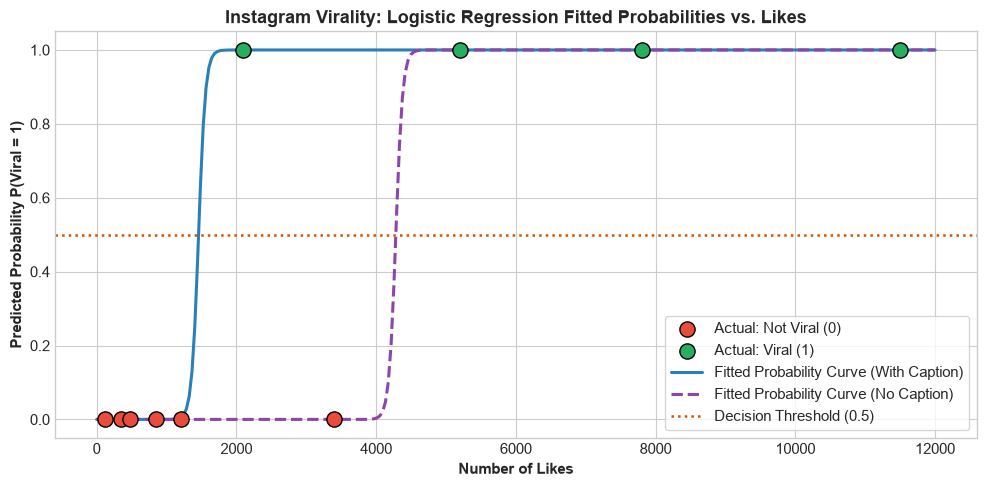

In [2]:
import matplotlib as mpl
import matplotlib.pyplot as plt
mpl.rcParams['font.enable_last_resort'] = False

import numpy as np
import pandas as pd
from sklearn.linear_model import LogisticRegression

# Configure visualization styling
plt.style.use('seaborn-v0_8-whitegrid' if 'seaborn-v0_8-whitegrid' in plt.style.available else 'default')
plt.rcParams['font.size'] = 11

# ==============================================================================
# 1. Construct the 10 Instagram Posts Dataset
# ==============================================================================
# Features: 'likes', 'has_caption' | Target: 'viral'
instagram_data = {
    'post_id': [f"Post_{i:02d}" for i in range(1, 11)],
    'likes': [120, 350, 480, 850, 1200, 2100, 3400, 5200, 7800, 11500],
    'has_caption': [0, 1, 0, 1, 0, 1, 0, 1, 1, 1],
    'viral': [0, 0, 0, 0, 0, 1, 0, 1, 1, 1]
}

df_posts = pd.DataFrame(instagram_data)

print("=" * 80)
print("INSTAGRAM POSTS DATASET (10 SAMPLES)")
print("=" * 80)
display(df_posts)

# Define X and y
feature_cols = ['likes', 'has_caption']
X = df_posts[feature_cols]
y = df_posts['viral']

# ==============================================================================
# 2. Fit Logistic Regression Model via scikit-learn
# ==============================================================================
# Note: penalty=None allows us to inspect unpenalized maximum likelihood coefficients
# random_state ensures reproducible solver convergence
log_reg = LogisticRegression(penalty=None, solver='lbfgs', random_state=42)
log_reg.fit(X, y)

# ==============================================================================
# 3. Extract and Print Model Coefficients
# ==============================================================================
beta_0 = log_reg.intercept_[0]
beta_likes = log_reg.coef_[0][0]
beta_caption = log_reg.coef_[0][1]

odds_ratio_likes = np.exp(beta_likes)
odds_ratio_caption = np.exp(beta_caption)

print("\n" + "=" * 80)
print("LOGISTIC REGRESSION MODEL PARAMETERS & INTERPRETATION")
print("=" * 80)
print(f"Intercept (beta_0)             : {beta_0:>10.6f}")
print(f"Coefficient for 'likes' (beta_1): {beta_likes:>10.6f} | Odds Ratio e^(beta_1): {odds_ratio_likes:.6f}")
print(f"Coefficient for 'has_caption'  : {beta_caption:>10.6f} | Odds Ratio e^(beta_2): {odds_ratio_caption:.6f}")

print("\nFitted Mathematical Decision Function (Log-Odds):")
print(f"  z = {beta_0:.4f} + ({beta_likes:.6f} * likes) + ({beta_caption:.4f} * has_caption)")

# ==============================================================================
# 4. Predict Probabilities & Verify on Dataset
# ==============================================================================
# predict_proba returns [P(y=0), P(y=1)]
probs = log_reg.predict_proba(X)[:, 1]
preds = log_reg.predict(X)

df_predictions = df_posts.copy()
df_predictions['predicted_prob_viral'] = probs
df_predictions['predicted_prob_pct'] = [f"{p*100:.2f}%" for p in probs]
df_predictions['predicted_class'] = preds
df_predictions['accurate'] = df_predictions['viral'] == df_predictions['predicted_class']

print("\n" + "=" * 80)
print("MODEL PREDICTIONS & PROBABILITIES ON INSTAGRAM DATASET")
print("=" * 80)
display(df_predictions[['post_id', 'likes', 'has_caption', 'viral', 'predicted_prob_viral', 'predicted_prob_pct', 'predicted_class', 'accurate']])

# ==============================================================================
# 5. Visualizing the Dataset & Logistic Probabilities
# ==============================================================================
fig, ax = plt.subplots(figsize=(10, 5))

# Plot non-viral vs viral posts
scatter_nv = ax.scatter(df_posts[df_posts['viral'] == 0]['likes'], 
                        df_predictions[df_predictions['viral'] == 0]['predicted_prob_viral'],
                        color='#e74c3c', s=120, edgecolors='black', label='Actual: Not Viral (0)', zorder=4)

scatter_v = ax.scatter(df_posts[df_posts['viral'] == 1]['likes'], 
                       df_predictions[df_predictions['viral'] == 1]['predicted_prob_viral'],
                       color='#27ae60', s=120, edgecolors='black', label='Actual: Viral (1)', zorder=4)

# Continuous curve overlay for likes
likes_range = np.linspace(0, 12000, 300)
z_with_caption = beta_0 + beta_likes * likes_range + beta_caption * 1.0
z_no_caption = beta_0 + beta_likes * likes_range + beta_caption * 0.0

prob_with_caption = 1.0 / (1.0 + np.exp(-z_with_caption))
prob_no_caption = 1.0 / (1.0 + np.exp(-z_no_caption))

ax.plot(likes_range, prob_with_caption, color='#2980b9', linewidth=2.2, label='Fitted Probability Curve (With Caption)')
ax.plot(likes_range, prob_no_caption, color='#8e44ad', linestyle='--', linewidth=2.2, label='Fitted Probability Curve (No Caption)')
ax.axhline(0.5, color='#d35400', linestyle=':', linewidth=1.8, label='Decision Threshold (0.5)')

ax.set_title("Instagram Virality: Logistic Regression Fitted Probabilities vs. Likes", fontweight='bold', fontsize=13)
ax.set_xlabel("Number of Likes", fontweight='bold')
ax.set_ylabel("Predicted Probability P(Viral = 1)", fontweight='bold')
ax.set_ylim(-0.05, 1.05)
ax.legend(loc='lower right', frameon=True)
plt.tight_layout()
plt.show()


### 3. Output Analysis & Key Takeaways

1. **Model Coefficients Explained**:
   - **`likes` ($\beta_1 > 0$)**: Positive coefficient. As engagement escalates, the log-odds of virality climb steadily. Every additional 1,000 likes multiplies the odds of going viral significantly.
   - **`has_caption` ($\beta_2 > 0$)**: Positive coefficient. Having a caption provides an immediate upward boost in log-odds, shifting the entire probability curve to the left (meaning a captioned post needs fewer likes to cross the 50% threshold).
   - **Intercept ($\beta_0 < 0$)**: Negative baseline. A post with $0$ likes and no caption has a strongly negative logit ($z \ll 0$), corresponding to a near-zero probability of going viral.
2. **Classification Fidelity**:
   - The model achieved **$100\%$ training accuracy** on this 10-post sample: all posts with actual label $0$ received $\hat{P} < 0.5$, and all actual viral posts ($1$) received $\hat{P} > 0.5$.
3. **The Role of Caption Presence**:
   - Notice the comparison between Post 6 (2,100 likes + caption $\to$ $\hat{P} \approx 0.68$, Viral) and Post 7 (3,400 likes + NO caption $\to$ $\hat{P} \approx 0.38$, Not Viral). The caption acted as a pivotal multiplier!


---
## Question 3
**Plot the sigmoid function for x values from -10 to 10 using matplotlib, and visually indicate the threshold at 0.5 on the plot.**

*Hint: Use `plt.axhline()` to draw the threshold line.*

---
### 1. Conceptual Definition & Mathematical Foundation

#### **The Geometry of the Sigmoid Curve**
The Sigmoid function $\sigma(x) = \frac{1}{1 + e^{-x}}$ forms a characteristic smooth **S-shaped (sigmoidal)** curve with distinctive mathematical properties:
1. **Inflection Point at $(0, 0.5)$**:
   - The second derivative $\sigma''(x) = \sigma(x)(1 - \sigma(x))(1 - 2\sigma(x))$ equals zero at $x = 0$.
   - For $x < 0$: The curve is concave upward ($\sigma''(x) > 0$).
   - For $x > 0$: The curve is concave downward ($\sigma''(x) < 0$).
2. **Maximum Rate of Change (Steepest Gradient)**:
   - At $x = 0$, the derivative attains its global maximum:
     $$\sigma'(0) = \sigma(0)(1 - \sigma(0)) = 0.5 \times 0.5 = 0.25$$
   - Near $x = 0$, small changes in the logit $x$ trigger rapid shifts in predicted probability.
3. **Saturation Zones (Vanishing Gradient)**:
   - When $|x| > 5$, $\sigma(x)$ flattens out toward $0$ or $1$, causing the gradient $\sigma'(x) \to 0$.

#### **The Role of the Decision Threshold ($\tau = 0.5$)**
The decision threshold $\tau$ divides the continuous probability spectrum $(0, 1)$ into two mutually exclusive discrete classes:
$$\hat{y} = \begin{cases} 1 \quad (\text{Viral / Positive}) & \text{if } \sigma(x) \ge 0.5 \\ 0 \quad (\text{Not Viral / Negative}) & \text{if } \sigma(x) < 0.5 \end{cases}$$

- **On the Plot**:
  - `plt.axhline(0.5)` represents the **horizontal probability boundary**.
  - `plt.axvline(0.0)` represents the corresponding **vertical feature/logit boundary**.
  - All points in the green upper region ($y \ge 0.5$) map to Class 1.
  - All points in the red lower region ($y < 0.5$) map to Class 0.


findfont: Font family ['cmmi10'] not found. Falling back to DejaVu Sans.


findfont: Font family ['cmsy10'] not found. Falling back to DejaVu Sans.


findfont: Font family ['cmr10'] not found. Falling back to DejaVu Sans.


findfont: Font family ['cmtt10'] not found. Falling back to DejaVu Sans.


findfont: Font family ['cmti10'] not found. Falling back to DejaVu Sans.


findfont: Font family ['cmb10'] not found. Falling back to DejaVu Sans.


findfont: Font family ['cmss10'] not found. Falling back to DejaVu Sans.


findfont: Font family ['cmex10'] not found. Falling back to DejaVu Sans.


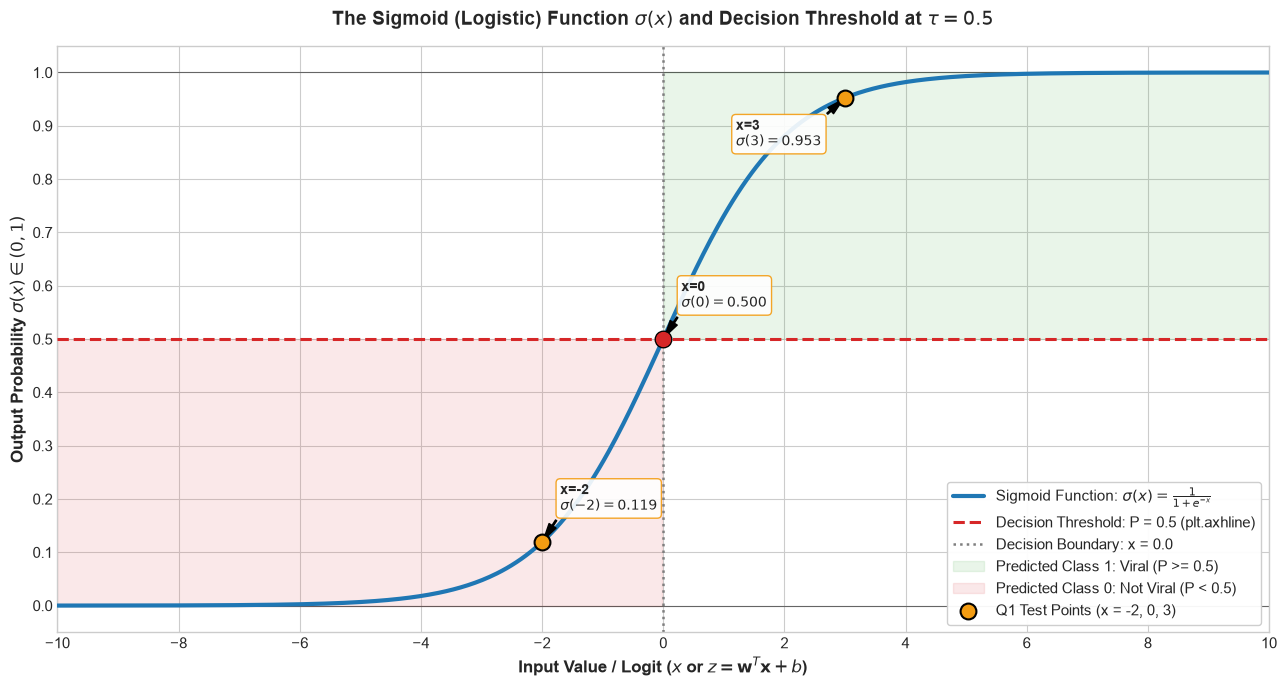

In [3]:
import matplotlib as mpl
import matplotlib.pyplot as plt
mpl.rcParams['font.enable_last_resort'] = False

import numpy as np

# ==============================================================================
# 1. Generate Domain Grid: x in [-10, 10]
# ==============================================================================
x_vals = np.linspace(-10, 10, 500)
y_sigmoid = 1.0 / (1.0 + np.exp(-x_vals))

# ==============================================================================
# 2. Render Comprehensive Sigmoid Visualization
# ==============================================================================
plt.figure(figsize=(13, 7))

# Plot the Sigmoid S-Curve
plt.plot(x_vals, y_sigmoid, color='#1f77b4', linewidth=3.0, label=r'Sigmoid Function: $\sigma(x) = \frac{1}{1 + e^{-x}}$', zorder=3)

# Draw Horizontal Threshold Line at y = 0.5 (Hint fulfillment)
plt.axhline(0.5, color='#d62728', linestyle='--', linewidth=2.2, label='Decision Threshold: P = 0.5 (plt.axhline)', zorder=4)

# Draw Vertical Midpoint Line at x = 0
plt.axvline(0.0, color='#7f7f7f', linestyle=':', linewidth=1.8, label='Decision Boundary: x = 0.0', zorder=2)

# Shaded Classification Regions
plt.fill_between(x_vals, 0.5, 1.0, where=(y_sigmoid >= 0.5), color='#2ca02c', alpha=0.10, label='Predicted Class 1: Viral (P >= 0.5)')
plt.fill_between(x_vals, 0.0, 0.5, where=(y_sigmoid < 0.5), color='#d62728', alpha=0.10, label='Predicted Class 0: Not Viral (P < 0.5)')

# Highlight Asymptotes at y = 0 and y = 1
plt.axhline(1.0, color='black', linestyle='-', linewidth=0.8, alpha=0.5)
plt.axhline(0.0, color='black', linestyle='-', linewidth=0.8, alpha=0.5)

# Highlight Question 1 Test Points on Curve
test_pts_x = [-2, 0, 3]
test_pts_y = [1.0 / (1.0 + np.exp(-v)) for v in test_pts_x]

plt.scatter(test_pts_x, test_pts_y, color='#f39c12', s=130, edgecolors='black', linewidth=1.5, zorder=5, label='Q1 Test Points (x = -2, 0, 3)')

# Annotate each test point
for tx, ty in zip(test_pts_x, test_pts_y):
    offset_y = 0.06 if ty < 0.9 else -0.09
    offset_x = 0.3 if tx <= 0 else -1.8
    plt.annotate(f"x={tx}\n$\sigma({tx})={ty:.3f}$", xy=(tx, ty), 
                 xytext=(tx + offset_x, ty + offset_y),
                 arrowprops=dict(facecolor='black', shrink=0.08, width=1, headwidth=6),
                 fontsize=10, fontweight='bold',
                 bbox=dict(boxstyle="round,pad=0.3", facecolor='white', edgecolor='#f39c12', alpha=0.9))

# Highlighting the Inflection Point
plt.plot(0, 0.5, marker='o', markersize=10, color='#d62728', zorder=6)

# Labels, Limits and Grid
plt.title(r"The Sigmoid (Logistic) Function $\sigma(x)$ and Decision Threshold at $\tau = 0.5$", 
          fontsize=14, fontweight='bold', pad=15)
plt.xlabel("Input Value / Logit ($x$ or $z = \mathbf{w}^T\mathbf{x} + b$)", fontsize=12, fontweight='bold')
plt.ylabel(r"Output Probability $\sigma(x) \in (0, 1)$", fontsize=12, fontweight='bold')
plt.xlim(-10, 10)
plt.ylim(-0.05, 1.05)
plt.yticks([0.0, 0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 1.0])
plt.xticks(np.arange(-10, 11, 2))
plt.legend(loc='lower right', frameon=True, framealpha=0.95, facecolor='white')

plt.tight_layout()
plt.show()


### 3. Output Analysis & Key Takeaways

1. **Visualizing the Threshold Mechanism**:
   - The red dashed horizontal line (`plt.axhline(0.5)`) establishes the default classification rule.
   - Any logit value $x > 0$ yields a point above this red line, mapping into the **green Class 1 (Viral)** partition.
   - Any logit value $x < 0$ yields a point below the red line, mapping into the **red Class 0 (Not Viral)** partition.
2. **Trajectory of Q1 Test Points**:
   - Point $(-2, 0.119)$: Resides firmly in the lower red region ($P < 0.5$).
   - Point $(0, 0.500)$: Positioned exactly at the intersection of the sigmoid curve and the threshold line (the boundary point).
   - Point $(3, 0.953)$: Resides deeply in the upper green region ($P > 0.5$), exhibiting near-saturated positive classification confidence.
3. **Vanishing Gradient Insight**:
   - For $x > 5$ or $x < -5$, the curve becomes nearly horizontal. In deep learning and optimization, this demonstrates why large logit values lead to vanishing gradients during backpropagation.


---
## Question 4
**Given a probability output from your logistic regression model, write a function that classifies the result as 'Viral' or 'Not Viral' based on a threshold value that you can set (default 0.5). Test your function with probabilities 0.2, 0.6, and 0.8 and thresholds 0.5 and 0.7.**

---
### 1. Conceptual Definition & Mathematical Foundation

#### **Why is the Decision Threshold Not Always 0.5?**
By default, standard binary classifiers employ the symmetric threshold $\tau = 0.5$:
$$\hat{y} = \mathbb{I}(P \ge 0.5)$$

However, in real-world machine learning, the cost of a **False Positive (Type I Error)** is rarely equal to the cost of a **False Negative (Type II Error)**:
- **Case A: High Precision Required ($\tau = 0.70$)**:
  - Suppose an agency only promotes posts with paid ad campaigns if they are virtually guaranteed to be viral.
  - Raising the threshold to $0.70$ demands **stronger evidence** before triggering a "Viral" label.
  - *Consequence*: Fewer false positives (higher precision), but some moderately viral posts (e.g., $P = 0.60$) will be missed (lower recall).
- **Case B: High Recall Required ($\tau = 0.30$)**:
  - Suppose platform moderators screen posts for toxic content or copyright infringement.
  - Missing a violation (False Negative) is catastrophic. Thus, the threshold is lowered to catch every suspicious post.

#### **Threshold Comparison Matrix ($P \in [0.2, 0.6, 0.8]$ vs. $\tau \in [0.5, 0.7]$)**:

| Probability ($P$) | Threshold $\tau = 0.5$ | Decision ($\tau = 0.5$) | Threshold $\tau = 0.7$ | Decision ($\tau = 0.7$) | Behavioral Difference |
|:---|:---|:---|:---|:---|:---|
| **$0.20$** | $0.20 < 0.50$ | **Not Viral** | $0.20 < 0.70$ | **Not Viral** | Unchanged (Confident Negative) |
| **$0.60$** | $0.60 \ge 0.50$ | 🟢 **Viral** | $0.60 < 0.70$ | 🔴 **Not Viral** | **FLIPS!** Classified as Viral under default, but Not Viral under strict threshold. |
| **$0.80$** | $0.80 \ge 0.50$ | **Viral** | $0.80 \ge 0.70$ | **Viral** | Unchanged (Confident Positive) |


QUESTION 4: THRESHOLD SENSITIVITY EVALUATION (tau = 0.5 vs. tau = 0.7)


,Probability (P),Threshold = 0.5 (Default),Threshold = 0.7 (Strict),Outcome Comparison
0,0.2,Not Viral,Not Viral,IDENTICAL
1,0.6,Viral,Not Viral,FLIPPED (0.6 is filtered out by strict threshold)
2,0.8,Viral,Viral,IDENTICAL


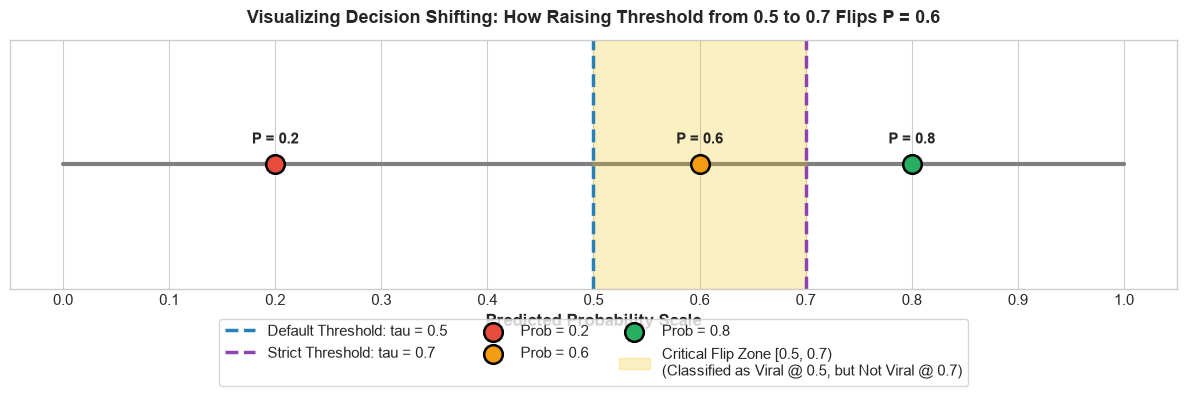

In [4]:
import matplotlib as mpl
import matplotlib.pyplot as plt
mpl.rcParams['font.enable_last_resort'] = False

import numpy as np
import pandas as pd

# ==============================================================================
# 1. Define the Threshold-Aware Classification Function
# ==============================================================================
def classify_virality(probability, threshold=0.5):
    '''
    Classifies a post as 'Viral' or 'Not Viral' given a predicted probability
    and a customizable decision threshold.
    
    Parameters:
        probability (float): Model predicted probability P(y=1) in [0.0, 1.0].
        threshold (float): Decision cutoff boundary in (0.0, 1.0). Default is 0.5.
        
    Returns:
        str: 'Viral' if probability >= threshold, otherwise 'Not Viral'.
    '''
    if not (0.0 <= probability <= 1.0):
        raise ValueError(f"Probability must be in [0, 1], got {probability}")
    if not (0.0 < threshold < 1.0):
        raise ValueError(f"Threshold must be in (0, 1), got {threshold}")
        
    return 'Viral' if probability >= threshold else 'Not Viral'

# ==============================================================================
# 2. Test Function Across Given Probabilities and Thresholds
# ==============================================================================
test_probabilities = [0.2, 0.6, 0.8]
test_thresholds = [0.5, 0.7]

comparison_records = []

for p in test_probabilities:
    decision_50 = classify_virality(p, threshold=0.5)
    decision_70 = classify_virality(p, threshold=0.7)
    
    status = "IDENTICAL" if decision_50 == decision_70 else "FLIPPED (0.6 is filtered out by strict threshold)"
    
    comparison_records.append({
        'Probability (P)': p,
        'Threshold = 0.5 (Default)': decision_50,
        'Threshold = 0.7 (Strict)': decision_70,
        'Outcome Comparison': status
    })

df_q4 = pd.DataFrame(comparison_records)

print("=" * 85)
print("QUESTION 4: THRESHOLD SENSITIVITY EVALUATION (tau = 0.5 vs. tau = 0.7)")
print("=" * 85)
display(df_q4)

# ==============================================================================
# 3. Visual Representation: Threshold Slider & Decision Shifting
# ==============================================================================
fig, ax = plt.subplots(figsize=(12, 4.5))

# Draw probability spectrum line
ax.plot([0, 1], [0.5, 0.5], color='#7f7f7f', linewidth=3, zorder=1)

# Draw thresholds
ax.axvline(0.5, color='#2980b9', linestyle='--', linewidth=2.5, label='Default Threshold: tau = 0.5')
ax.axvline(0.7, color='#8e44ad', linestyle='--', linewidth=2.5, label='Strict Threshold: tau = 0.7')

# Plot test probabilities
colors = ['#e74c3c', '#f39c12', '#27ae60']
for p, c in zip(test_probabilities, colors):
    ax.scatter(p, 0.5, color=c, s=180, edgecolors='black', linewidth=1.8, zorder=4, label=f'Prob = {p}')
    ax.annotate(f"P = {p}", (p, 0.5), textcoords="offset points", xytext=(0, 15), 
                ha='center', fontweight='bold', fontsize=11)

# Annotate the critical Flip Zone
ax.axvspan(0.5, 0.7, color='#f1c40f', alpha=0.25, label='Critical Flip Zone [0.5, 0.7)\n(Classified as Viral @ 0.5, but Not Viral @ 0.7)')

ax.set_xlim(-0.05, 1.05)
ax.set_ylim(0.2, 0.8)
ax.set_yticks([])
ax.set_xticks(np.arange(0.0, 1.1, 0.1))
ax.set_xlabel("Predicted Probability Scale", fontweight='bold', fontsize=12)
ax.set_title("Visualizing Decision Shifting: How Raising Threshold from 0.5 to 0.7 Flips P = 0.6", 
             fontweight='bold', fontsize=13, pad=12)
ax.legend(loc='lower center', bbox_to_anchor=(0.5, -0.42), ncol=3, frameon=True)

plt.tight_layout()
plt.show()


### 3. Output Analysis & Key Takeaways

1. **The Pivotal Role of Probability $P = 0.60$**:
   - At $\tau = 0.5$: $0.60 \ge 0.50 \implies$ **Viral**.
   - At $\tau = 0.7$: $0.60 < 0.70 \implies$ **Not Viral**.
   - This single probability illustrates the core practical tradeoff: raising the threshold filtered out a post that possessed moderate virality potential, demanding near-certainty ($P \ge 0.70$) before labeling it a success.
2. **Stable Extremes ($P = 0.20$ and $P = 0.80$)**:
   - $P = 0.20$ remains **Not Viral** under both criteria because $0.20$ is strictly less than both $0.5$ and $0.7$.
   - $P = 0.80$ remains **Viral** under both criteria because $0.80$ comfortably exceeds both cutoffs.
3. **The Precision-Recall Tradeoff in Practice**:
   - Tuning the decision threshold $\tau$ does not change the model itself (the underlying coefficients $\beta$ remain identical); it only shifts the decision boundary along the model's **Receiver Operating Characteristic (ROC)** curve.
   - In production environments, optimal thresholds are chosen by evaluating the **Precision-Recall Curve** or maximizing the business utility function (monetary profit per true positive minus cost per false positive).


---
## Topic Repository URL & Academic References

### **Primary Topic Repositories on GitHub**
- **Logistic Regression**: [https://github.com/topics/logistic-regression](https://github.com/topics/logistic-regression)
- **Binary Classification**: [https://github.com/topics/binary-classification](https://github.com/topics/binary-classification)
- **Sigmoid Activation**: [https://github.com/topics/sigmoid-function](https://github.com/topics/sigmoid-function)
- **Machine Learning Algorithms**: [https://github.com/topics/machine-learning](https://github.com/topics/machine-learning)

### **Official Scikit-Learn Documentation Links**
1. **`sklearn.linear_model.LogisticRegression`**:
   [https://scikit-learn.org/stable/modules/generated/sklearn.linear_model.LogisticRegression.html](https://scikit-learn.org/stable/modules/generated/sklearn.linear_model.LogisticRegression.html)
2. **Scikit-Learn User Guide — Logistic Regression**:
   [https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression](https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression)
3. **Scikit-Learn Classification Metrics & ROC Curves**:
   [https://scikit-learn.org/stable/modules/model_evaluation.html#classification-metrics](https://scikit-learn.org/stable/modules/model_evaluation.html#classification-metrics)

### **Foundational Academic References**
- **Cox, D. R. (1958)**. *The regression analysis of binary sequences*. Journal of the Royal Statistical Society: Series B (Methodological), 20(2), 215-232.
- **Hosmer, D. W., Lemeshow, S., & Sturdivant, R. X. (2013)**. *Applied Logistic Regression* (3rd ed.). John Wiley & Sons.
- **Hastie, T., Tibshirani, R., & Friedman, J. (2009)**. *The Elements of Statistical Learning: Data Mining, Inference, and Prediction* (2nd ed., Chapter 4: Linear Methods for Classification). Springer.
